### Imports

In [18]:
# Imports
import torch
from typing import List, Tuple
from dataclasses import dataclass
import signatory

import numpy as np
import torch
import pickle
import os
from pathlib import Path
import bz2
import pandas as pd
import plotly.io as pio
pio.templates.default = 'plotly_white'
from minisom import MiniSom
from collections import Counter
from datetime import datetime
from statsmodels.tsa.arima_process import ArmaProcess
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,accuracy_score,jaccard_score
from scipy.optimize import linear_sum_assignment
from sklearn.linear_model import Lasso
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import sys
# This is need to get the imports from SIGSOM and jump-models
sys.path.insert(0, os.path.abspath('../'))
# helper functions
from SIGSOM.sigsom.utils.helpers import logger, SOMParams
# signature transforms
import SIGSOM.sigsom.signatures.signature_transforms as st
# som
from SIGSOM.sigsom.som.som import SOM
from SIGSOM.sigsom.som.som_mahalanobis import SOMM
from SIGSOM.sigsom.som.adapted_som import GSOMM

from sklearn.preprocessing import PowerTransformer, MinMaxScaler


### Stocks


In [2]:
def rolling_window1(x: torch.Tensor, window: int) -> torch.Tensor:
    N = (x.shape[0]-1) // (window-1)
    result = torch.empty((N, window, x.shape[1]))
    for i in range(N):
        if i == 0:
            result[i, :, :] = x[0:window, :]
        else:
            result[i, :, :] = x[(i*(window))-i: (window*(i+1))-i,:]

    return result

In [3]:
folder_path = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\data\parquet_files"
folder_files = os.listdir(folder_path)
parquet_files = [f for f in folder_files if f.endswith('.parquet')]
stock_dict = {}
for file in parquet_files:
    file_path = os.path.join(folder_path, file)
    df_name = os.path.splitext(file)[0] 
    stock_dict[df_name] = pd.read_parquet(file_path)  
for df_name, df in stock_dict.items():
    print(f"DataFrame for {df_name}:")
    print(df.head())  

DataFrame for AAPL_full_1min_adjsplit:
              datetime    open    high     low   close  volume
0  2005-01-03 08:00:00  1.1607  1.1613  1.1607  1.1613   39200
1  2005-01-03 08:02:00  1.1518  1.1518  1.1518  1.1518  304360
2  2005-01-03 08:03:00  1.1625  1.1627  1.1625  1.1627   16800
3  2005-01-03 08:04:00  1.1634  1.1661  1.1634  1.1661  161504
4  2005-01-03 08:07:00  1.1645  1.1645  1.1643  1.1643   50400
DataFrame for GE_full_1min_adjsplitdiv:
              datetime      open      high       low     close  volume
0  2005-01-03 08:01:00  115.5667  115.5667  115.5667  115.5667   318.0
1  2005-01-03 08:02:00  115.5667  115.5667  115.5667  115.5667   127.0
2  2005-01-03 08:04:00  115.7242  115.7242  115.7242  115.7242    31.8
3  2005-01-03 08:05:00  115.7242  115.7242  115.6612  115.6612   413.0
4  2005-01-03 08:10:00  115.7242  115.7242  115.7242  115.7242    63.5
DataFrame for JPM_full_1min_adjsplitdiv:
              datetime     open     high      low    close     volume
0  200

### find common start data

In [4]:
aapl_dates = stock_dict["AAPL_full_1min_adjsplit"]["datetime"]
tsla_dates = stock_dict["TSLA_full_1min_adjsplit"]["datetime"]
jpm_dates = stock_dict["JPM_full_1min_adjsplitdiv"]["datetime"]
ge_dates = stock_dict["GE_full_1min_adjsplitdiv"]["datetime"]

# # Find the latest start date
common_start_date = max(aapl_dates[0], tsla_dates[0], jpm_dates[0], ge_dates[0])
common_start_date

'2010-06-29 11:25:00'

In [5]:
# import pandas as pd

# # Assuming stock_dict contains the data
# df_aapl = stock_dict["AAPL_full_1min_adjsplit"]

# # Ensure the 'datetime' column is in datetime format
# df_aapl['datetime'] = pd.to_datetime(df_aapl.index)

# # Filter the data between the specified dates
# df_filtered = df_aapl[(df_aapl['datetime'] >= '2022-01-01') & (df_aapl['datetime'] <= '2023-10-05')]

# # Calculate the frequency of datetime intervals
# datetime_diffs = df_filtered['datetime'].diff().dropna()

# # Get the unique time intervals and their frequency counts
# interval_freq = datetime_diffs.value_counts()

# # Display the frequency of datetime intervals
# print(interval_freq[:20])


In [6]:
import pandas as pd

# Define a function to resample the data for one stock
def resample_stock_data(stock_data, resample_rule='5T', start_date=None):
    # Convert the 'datetime' column to datetime format
    stock_data['datetime'] = pd.to_datetime(stock_data['datetime'])
    
    # Set 'datetime' as the index
    stock_data.set_index('datetime', inplace=True)
    
    # Define the end date as one year after the start date
    end_date = pd.to_datetime(start_date) + pd.DateOffset(years=2)
    
    # Filter data for the one-year period starting from common_start_date
    stock_data = stock_data.loc[start_date:end_date]
    
    # Resample and aggregate
    resampled_data = stock_data.resample(resample_rule).agg({
        'close': 'last',  # Last price in the 5-minute window
    })
    
    # Handle missing data by forward filling
    resampled_data.ffill(inplace=True)
    
    return resampled_data

# Use the common start date and calculate one year forward
start_date = common_start_date

# Resample all stocks and store them in a dictionary
resampled_stock_dict = {}
for stock_name in ["AAPL_full_1min_adjsplit", "TSLA_full_1min_adjsplit", "JPM_full_1min_adjsplitdiv", "GE_full_1min_adjsplitdiv"]:
    stock_data = stock_dict[stock_name]
    resampled_stock_dict[stock_name] = resample_stock_data(stock_data, start_date=start_date)

# Display the first 10 rows of resampled AAPL data as an example
print(resampled_stock_dict["AAPL_full_1min_adjsplit"].head(10))


                      close
datetime                   
2010-06-29 11:25:00  9.2129
2010-06-29 11:30:00  9.1975
2010-06-29 11:35:00  9.2020
2010-06-29 11:40:00  9.1900
2010-06-29 11:45:00  9.1989
2010-06-29 11:50:00  9.1861
2010-06-29 11:55:00  9.1771
2010-06-29 12:00:00  9.1661
2010-06-29 12:05:00  9.1686
2010-06-29 12:10:00  9.1789


In [7]:
resampled_stock_dict1 = {}
for stock_name, stock_data in resampled_stock_dict.items():
    print(f"Processing stock: {stock_name}")
    
    # Select the 'close' price column
    data = stock_data[["close"]]
    data = data.values
    
    # Convert to a Tensor
    data = torch.tensor(data, dtype=torch.float32)
    
    # Get 5-minute data
    data_5min1 = data  # If no further reshaping or averaging is needed as per your steps
    
    # Reshape and prepare subwindows (assuming window size for 10 days at 96 intervals per day)
    window_size = 96 * 10 #days of 5-minute intervals
    data_5min_1 = rolling_window1(data_5min1, window=window_size)
    
    # Normalize each window by subtracting the first element and dividing by the standard deviation
    data_5min_1 = data_5min_1 - data_5min_1[:, 0:1]  # Subtract the first element of each window
    std_dev = torch.std(data_5min_1, dim=1, keepdim=True)

    # Replace zero standard deviations with 1 to avoid division by zero
    std_dev[std_dev == 0] = 1.0

    # Perform normalization safely
    data_5min_1 /= std_dev

    # data_5min_1 /= torch.std(data_5min_1, dim=1, keepdim=True)  # Normalize by standard deviation
    
    # Now `data_5min_1` contains the normalized rolling window data for this stock
    
    # Optionally, you can store the processed data back into a new dictionary
    resampled_stock_dict1[stock_name] = data_5min_1

    # Display or further process `data_5min_1` as needed
    print(f"Processed data for {stock_name}: {data_5min_1.shape}")

Processing stock: AAPL_full_1min_adjsplit
Processed data for AAPL_full_1min_adjsplit: torch.Size([219, 960, 1])
Processing stock: TSLA_full_1min_adjsplit
Processed data for TSLA_full_1min_adjsplit: torch.Size([219, 960, 1])
Processing stock: JPM_full_1min_adjsplitdiv
Processed data for JPM_full_1min_adjsplitdiv: torch.Size([219, 960, 1])
Processing stock: GE_full_1min_adjsplitdiv
Processed data for GE_full_1min_adjsplitdiv: torch.Size([219, 960, 1])


In [8]:
multivariate_path=torch.cat([resampled_stock_dict1["AAPL_full_1min_adjsplit"][:],resampled_stock_dict1["JPM_full_1min_adjsplitdiv"][:], resampled_stock_dict1["GE_full_1min_adjsplitdiv"][:]], dim=2)
multivariate_path = multivariate_path[:192,:,:]
multivariate_path.shape

torch.Size([192, 960, 3])

In [9]:
# Calculate the global minimum and maximum across all paths and time steps for each feature
data_min = multivariate_path.min(dim=0, keepdim=True)[0].min(dim=1, keepdim=True)[0]  # Global minimum per feature
data_max = multivariate_path.max(dim=0, keepdim=True)[0].max(dim=1, keepdim=True)[0]  # Global maximum per feature

# Apply Min-Max scaling: (data - min) / (max - min)
scaled_data = (multivariate_path - data_min) / (data_max - data_min)

# Check the range of the scaled data to confirm it's between 0 and 1
scaled_data_min = scaled_data.min().item()
scaled_data_max = scaled_data.max().item()

scaled_data_min, scaled_data_max


(0.0, 1.0)

In [10]:
import torch
import math
import math
from sympy import mobius, divisors

# Augmentations
augmentations = [
    (st.lead_lag_transform, {}),
]

# Transforms
transforms = [(st.log_singature, {"depth": 3, "basepoint": False})]

# Function to calculate the number of terms at a given depth
# def num_terms_at_depth(dimension, depth):
#     """
#     Compute the number of signature terms at a given depth.
#     Args:
#     - dimension: The number of input dimensions (e.g., 6).
#     - depth: The signature depth.

#     Returns:
#     - Number of signature terms at that depth.
#     """
#     from math import comb  # Python 3.8+ has the comb function for combinatorics
#     return comb(dimension + depth - 1, depth)

def num_terms_at_depth(d, n):
    """
    Compute the number of terms in the log signature at depth n using the given formula.
    
    Args:
    - d: Dimension of the input path.
    - n: Depth level.

    Returns:
    - Number of log signature terms at depth n.
    """
    result = 0
    for m in divisors(n):
        result += mobius(m) * d**(n // m)
    return result // n

# Function to rescale signature terms by the factorial of the depth level
def rescale_signature_by_factorial(signature, dimension, depth):
    """
    Multiplies the terms in the signature by the factorial of their respective depth level.
    Args:
    - signature: The signature tensor.
    - dimension: The number of input dimensions.
    - depth: The maximum depth of the signature.

    Returns:
    - Rescaled signature (factorial-weighted by depth level).
    """
    rescaled_signature = []

    current_index = 0

    for d in range(1, depth + 1):
        # Calculate the number of terms at this depth level
        n_terms_at_depth_d = num_terms_at_depth(dimension, d)

        # Compute factorial of the current depth level
        depth_factorial = math.factorial(d)

        # Extract the terms for the current depth and multiply by the depth factorial
        terms_at_depth_d = signature[..., current_index:current_index + n_terms_at_depth_d] * depth_factorial

        # Append the rescaled terms to the rescaled_signature list
        rescaled_signature.append(terms_at_depth_d)

        # Update the index
        current_index += n_terms_at_depth_d

    # Concatenate rescaled terms along the feature dimension
    return torch.cat(rescaled_signature, dim=-1)

# Pipeline function
def apply_pipeline(data, augmentations, transforms):
    results = {}
    for func, kwargs in augmentations:
        aug = func(data, **kwargs)  # Apply augmentation
        for trans, trans_kwargs in transforms:
            sig = trans(aug, **trans_kwargs)  # Apply transformation (e.g., log signature)

            # Rescale the signature terms by depth factorial on the feature dimension (not the batch)
            depth = trans_kwargs["depth"]
            dimension = aug.shape[1]  # Number of input dimensions (e.g., 6)
            rescaled_sig = rescale_signature_by_factorial(sig, dimension, depth)

            # Generate key for storing results
            if isinstance(func, tuple):
                key = f"{func[0].__name__}_{trans.__name__}"
            else:
                key = f"{func.__name__}_{trans.__name__}"

            results[key] = rescaled_sig

    return results

# Example usage with multivariate path (6-dimensional tensor)
# Assuming multivariate_path is a tensor of shape [8000, 6]

# Apply the pipeline
results1 = apply_pipeline(multivariate_path[:8000], augmentations, transforms)

# Print the shape of the rescaled signature output
print(results1["lead_lag_transform_log_singature"].shape)


torch.Size([192, 91])


# Save Signatures for Autoencoding

In [11]:
torch.save(results1["lead_lag_transform_log_singature"], "scaled_multivariate_stocks")
print(results1["lead_lag_transform_log_singature"].shape)

torch.Size([192, 91])


### VIF

In [12]:
# Function to calculate VIF
def calculate_vif(x):
    vif = [variance_inflation_factor(x.cpu().numpy(), i) for i in range(x.shape[1])]
    return torch.tensor(vif)

# Function to remove features with high VIF
def remove_vif(x, threshold=10):
    while True and x.shape[1] > 1:
        vif = calculate_vif(x)
        max_vif = torch.max(vif)  # check if largest value below threshold
        if max_vif <= threshold:
            break
        feature_to_remove = torch.argmax(vif)  # get index
        x = torch.cat((x[:, :feature_to_remove], x[:, feature_to_remove + 1:]), dim=1)  # remove highest vif
    return x

vif_cleaned_result = remove_vif(results1["lead_lag_transform_log_singature"], threshold=4)
vif_cleaned_result.shape

torch.Size([192, 13])

### Fit

In [14]:
import torch
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from datetime import datetime
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA

# Initializing variables to store the best model and the lowest quantization error
best_gsomm = None
lowest_quantization_error = float('inf')

# Perform the process 20 times
for i in range(20):
    print(f"Run {i+1}/20")

    # Preprocess the data
    scaler = PowerTransformer(method='yeo-johnson', standardize=True)
    data_scaled = scaler.fit_transform(vif_cleaned_result[:100,:])#[:,[0,1,2]])

    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_matrix = scaler.fit_transform(data_scaled)

    train_matrix1 = torch.tensor(data_scaled, dtype=torch.float32)

    # Set SOM parameters
    params = SOMParams(map_size=(2, 1), Tmax=6, Tmin=.1, batch_size=512, iterations=1000,
                       input_dims=train_matrix1.shape[1], lr=0.01,
                       dump_path=r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Simulations\results")

    gsomm = GSOMM(logger=logger, params=params)
    gsomm.somm.initialize(train_matrix1)

    # Train the SOM and calculate quantization error
    inital_preds2, initial_quantization_error = gsomm.initial_train(X_train=train_matrix1)

    # Compare the quantization error to find the best model
    if initial_quantization_error < lowest_quantization_error:
        lowest_quantization_error = initial_quantization_error
        best_gsomm = gsomm
        print(f"New best model found with quantization error: {initial_quantization_error.item()}")

# Output the lowest quantization error and the best model
print(f"Lowest quantization error: {lowest_quantization_error.item()}")


2025-02-17 21:31:18,818     adapted_som INFO     MainThread   MainProcess Training Initial SOMM
2025-02-17 21:31:18,819     adapted_som INFO     MainThread   MainProcess Save interval: 50


c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\torch\_tensor.py:575: UserWarning: floor_divide is deprecated, and will be removed in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values.
To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor'). (Triggered internally at  ..\aten\src\ATen\native\BinaryOps.cpp:467.)
  return torch.floor_divide(self, other)
2025-02-17 21:31:18,899     adapted_som INFO     MainThread   MainProcess Iteration 49 - T=N/A
2025-02-17 21:31:18,900     adapted_som INFO     MainThread   MainProcess   [Train] - L = 25.435, L_km = 12.70199966430664
2025-02-17 21:31:18,901     adapted_som INFO     MainThread   MainProcess   [Train] - L = 25.435, som_loss = 25.434999465942383


Run 1/20
updated
tensor(12.7017)


2025-02-17 21:31:31,572     adapted_som INFO     MainThread   MainProcess Iteration 99 - T=N/A
2025-02-17 21:31:31,572     adapted_som INFO     MainThread   MainProcess   [Train] - L = 24.978, L_km = 12.795000076293945
2025-02-17 21:31:31,572     adapted_som INFO     MainThread   MainProcess   [Train] - L = 24.978, som_loss = 24.97800064086914


tensor(12.7947)


...

tensor(12.1556)


2025-02-17 21:33:53,897     adapted_som INFO     MainThread   MainProcess Iteration 949 - T=N/A
2025-02-17 21:33:53,897     adapted_som INFO     MainThread   MainProcess   [Train] - L = 12.155, L_km = 12.154999732971191
2025-02-17 21:33:53,897     adapted_som INFO     MainThread   MainProcess   [Train] - L = 12.155, som_loss = 12.154999732971191


tensor(12.1555)


2025-02-17 21:33:54,239     adapted_som INFO     MainThread   MainProcess Iteration 999 - T=N/A
2025-02-17 21:33:54,239     adapted_som INFO     MainThread   MainProcess   [Train] - L = 12.155, L_km = 12.154999732971191
2025-02-17 21:33:54,239     adapted_som INFO     MainThread   MainProcess   [Train] - L = 12.155, som_loss = 12.154999732971191


tensor(12.1554)
Lowest quantization error: 1206.6650390625


In [15]:
resampled_stock_dict["GE_full_1min_adjsplitdiv"]

,close
datetime,
2010-06-29 11:25:00,52.2133
2010-06-29 11:30:00,52.2170
2010-06-29 11:35:00,52.3549
2010-06-29 11:40:00,52.2859
2010-06-29 11:45:00,52.4530
...,...
2012-06-29 11:05:00,78.2884
2012-06-29 11:10:00,78.3265
2012-06-29 11:15:00,78.4027


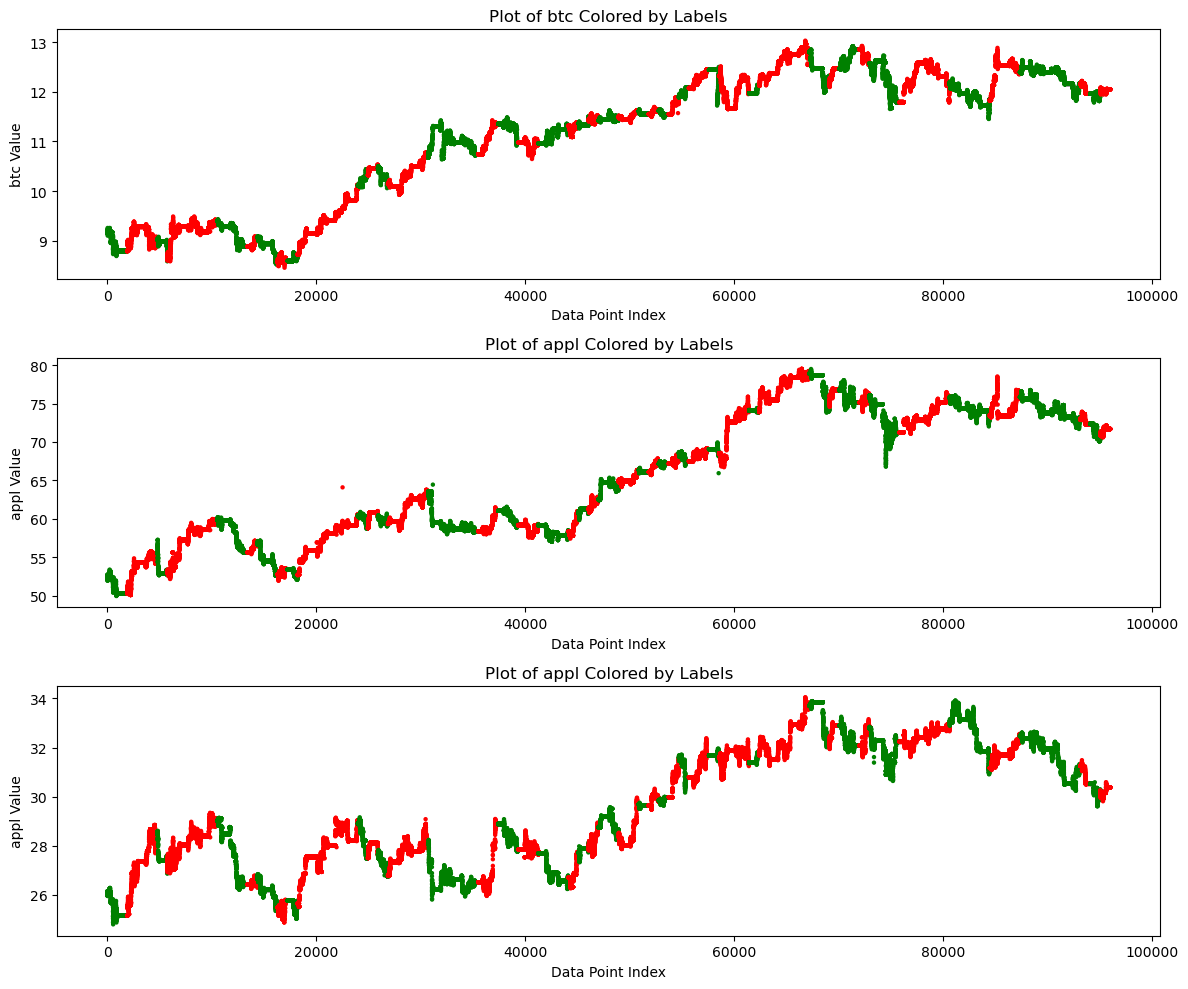

In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Assuming initial_preds_rep is already defined and repeated correctly
a,qe,_ = best_gsomm.predict(train_matrix1)

initial_preds_rep = np.repeat(np.array(a).flatten(), 10*96)


# Assuming eth and btc data are already extracted
btc = resampled_stock_dict["AAPL_full_1min_adjsplit"]["close"].values[:96000]
eth = resampled_stock_dict["GE_full_1min_adjsplitdiv"]["close"].values[:96000]
ada = resampled_stock_dict["JPM_full_1min_adjsplitdiv"]["close"].values[:96000]

# Define the custom colormap: red, blue, and green for your mapped labels
custom_cmap = ListedColormap(['red', 'green'])

# Create figure with two subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 10))

# Plot ETH in the top subplot
axs[0].scatter(np.arange(len(btc[:96000])), btc[:96000],
               c=initial_preds_rep[:96000], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs[0].set_title('Plot of btc Colored by Labels')
axs[0].set_xlabel('Data Point Index')
axs[0].set_ylabel('btc Value')

# Plot BTC in the bottom subplot
axs[1].scatter(np.arange(len(eth[:96000])), eth[:96000],
               c=initial_preds_rep[:96000], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs[1].set_title('Plot of appl Colored by Labels')
axs[1].set_xlabel('Data Point Index')
axs[1].set_ylabel('appl Value')

# Plot BTC in the bottom subplot
axs[2].scatter(np.arange(len(ada[:96000])), ada[:96000],
               c=initial_preds_rep[:96000], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs[2].set_title('Plot of appl Colored by Labels')
axs[2].set_xlabel('Data Point Index')
axs[2].set_ylabel('appl Value')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


### Plots

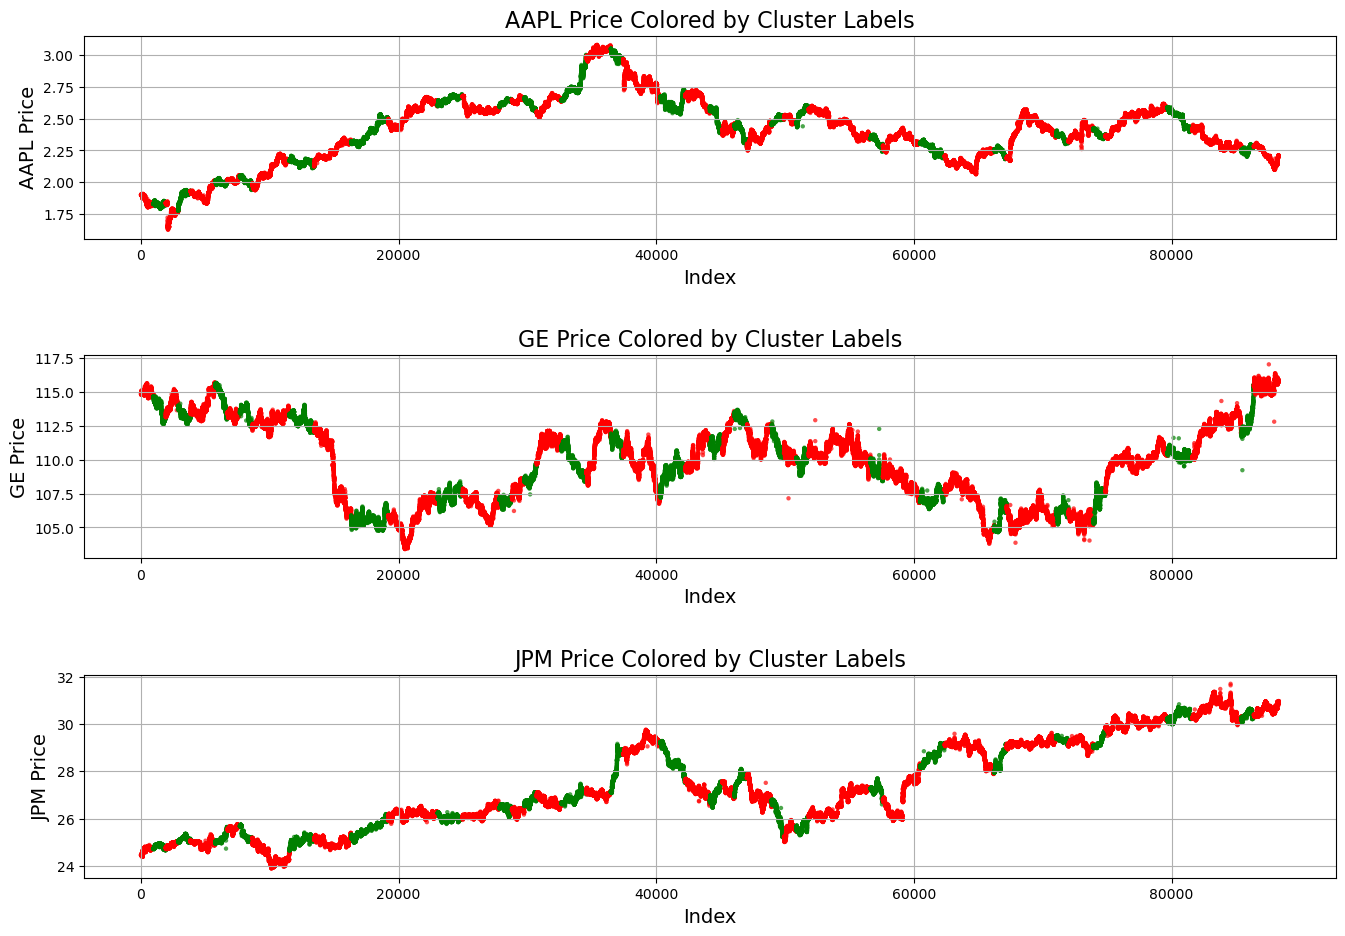

In [20]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_data = scaler.fit_transform(vif_cleaned_result[100:])
scaled_data = min_max_scaler.fit_transform(scaled_data)
test_matrix = torch.tensor(scaled_data, dtype=torch.float32)

# Step 3: Get predictions and quantization error
test_preds, qe, proto = best_gsomm.predict(test_matrix)  # Replace 'gsomm.predict' with your method
test_preds = np.array(test_preds).flatten()
initial_preds_rep = np.repeat(test_preds, 10*96)
initial_preds_rep.shape


# Assuming eth, btc, and ada data are already extracted
# Assuming eth and btc data are already extracted
btc = stock_dict["AAPL_full_1min_adjsplit"]["close"].values[96000:]
eth = stock_dict["GE_full_1min_adjsplitdiv"]["close"].values[96000:]
ada = stock_dict["JPM_full_1min_adjsplitdiv"]["close"].values[96000:]

# Define the custom colormap: green for one label, red for the other
custom_cmap = ListedColormap(['red', 'green'])

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(14, 10))  # Increased figure size

# Plot BTC in the first subplot
axs[0].scatter(np.arange(len(btc[:88320])), btc[:88320],
               c=initial_preds_rep[:], cmap=custom_cmap, s=10, alpha=0.7, edgecolor='none')
axs[0].set_title('AAPL Price Colored by Cluster Labels', fontsize=16)
axs[0].set_xlabel('Index', fontsize=14)
axs[0].set_ylabel('AAPL Price', fontsize=14)
axs[0].grid(True)  # Add grid

# Plot ETH in the second subplot
axs[1].scatter(np.arange(len(eth[:88320])), eth[:88320],
               c=initial_preds_rep[:], cmap=custom_cmap, s=10, alpha=0.7, edgecolor='none')
axs[1].set_title('GE Price Colored by Cluster Labels', fontsize=16)
axs[1].set_xlabel('Index', fontsize=14)
axs[1].set_ylabel('GE Price', fontsize=14)
axs[1].grid(True)  # Add grid

# Plot ADA in the third subplot
axs[2].scatter(np.arange(len(ada[:88320])), ada[:88320],
               c=initial_preds_rep[:], cmap=custom_cmap, s=10, alpha=0.7, edgecolor='none')
axs[2].set_title('JPM Price Colored by Cluster Labels', fontsize=16)
axs[2].set_xlabel('Index', fontsize=14)
axs[2].set_ylabel('JPM Price', fontsize=14)
axs[2].grid(True)  # Add grid

# Improve layout and add padding
plt.tight_layout(pad=3.0)
plt.savefig("Multivariate_Stocks.png")
# Show the plot
plt.show()


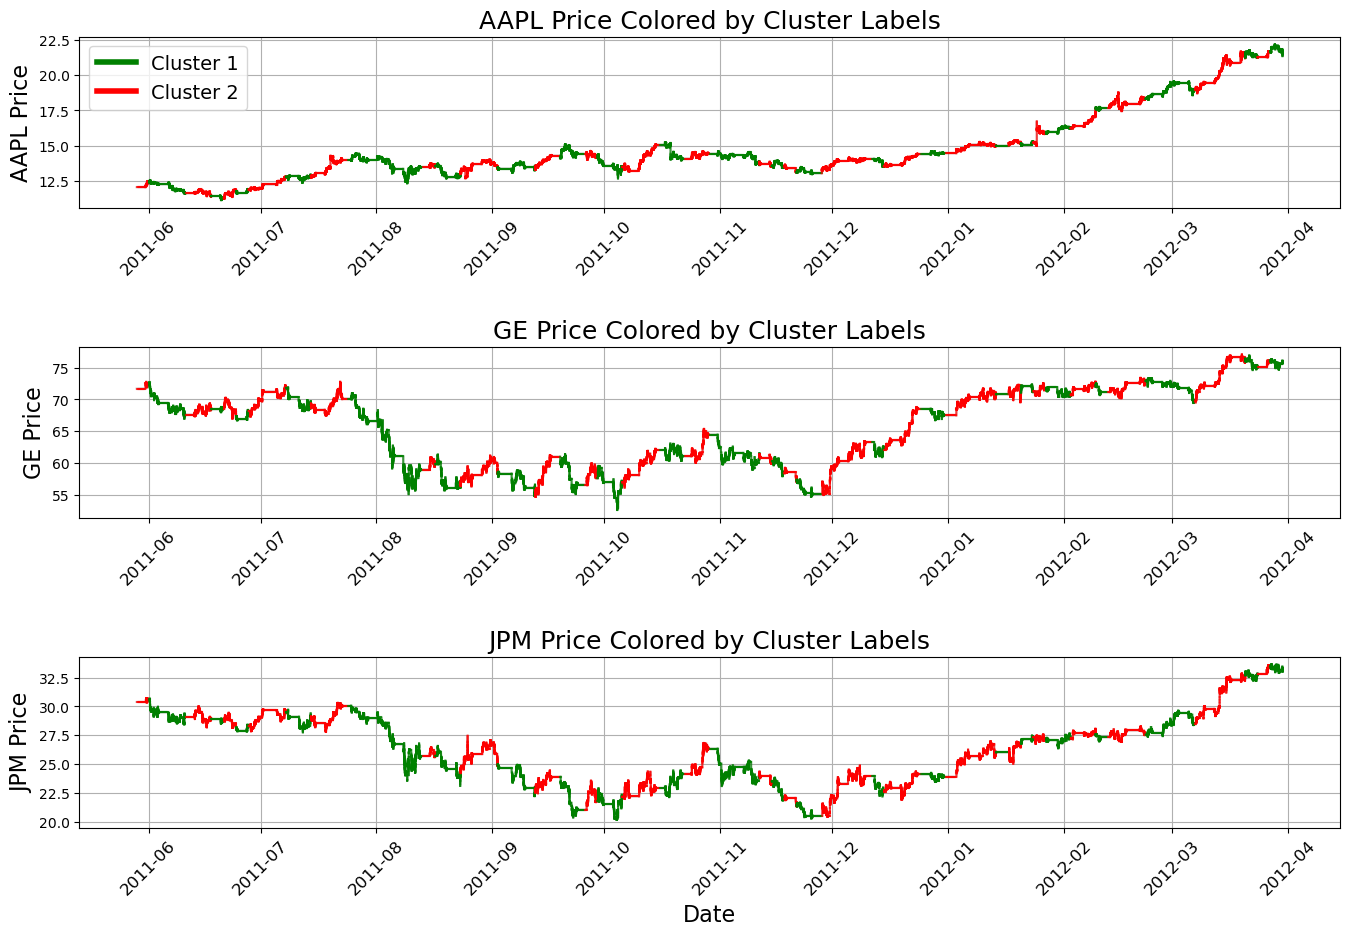

In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D  # For creating custom legend entries

scaler = PowerTransformer(method='yeo-johnson', standardize=True)
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))

# Assuming scalers, gsomm, and resampled data are already defined
scaled_data = scaler.fit_transform(vif_cleaned_result[100:])
scaled_data = min_max_scaler.fit_transform(scaled_data)
test_matrix = torch.tensor(scaled_data, dtype=torch.float32)

# Step 3: Get predictions and quantization error
test_preds, qe, proto = best_gsomm.predict(test_matrix)  # Replace 'gsomm.predict' with your method
test_preds = np.array(test_preds).flatten()

initial_preds_rep = np.repeat(test_preds, 10 * 96)
initial_preds_rep.shape

# Assuming eth, btc, and ada data are already extracted
btc = resampled_stock_dict["AAPL_full_1min_adjsplit"]["close"].values[96000:]
eth = resampled_stock_dict["GE_full_1min_adjsplitdiv"]["close"].values[96000:]
ada = resampled_stock_dict["JPM_full_1min_adjsplitdiv"]["close"].values[96000:]

# Get the actual date-times from the resampled AAPL data
btc_dates = resampled_stock_dict["AAPL_full_1min_adjsplit"]["close"].index[96000:]

# Define the custom colormap: green for one label, red for the other
custom_cmap = ListedColormap(['red', 'green'])

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(14, 10))  # Increased figure size

# Plot AAPL as lines
axs[0].plot(btc_dates[:88320], btc[:88320], color='gray', alpha=0.4)  # Plot entire AAPL data in light color
for i in range(len(btc[:88320]) - 1):
    axs[0].plot([btc_dates[i], btc_dates[i+1]], [btc[i], btc[i+1]], color=custom_cmap(initial_preds_rep[i]), alpha=0.7)

# Set title and labels for AAPL
axs[0].set_title('AAPL Price Colored by Cluster Labels', fontsize=18)
# axs[0].set_xlabel('Date', fontsize=16)
axs[0].set_ylabel('AAPL Price', fontsize=16)
axs[0].grid(True)

# Plot GE as lines
axs[1].plot(btc_dates[:88320], eth[:88320], color='gray', alpha=0.4)  # Plot entire GE data in light color
for i in range(len(eth[:88320]) - 1):
    axs[1].plot([btc_dates[i], btc_dates[i+1]], [eth[i], eth[i+1]], color=custom_cmap(initial_preds_rep[i]), alpha=0.7)

# Set title and labels for GE
axs[1].set_title('GE Price Colored by Cluster Labels', fontsize=18)
# axs[1].set_xlabel('Date', fontsize=16)
axs[1].set_ylabel('GE Price', fontsize=16)
axs[1].grid(True)

# Plot JPM as lines
axs[2].plot(btc_dates[:88320], ada[:88320], color='gray', alpha=0.4)  # Plot entire JPM data in light color
for i in range(len(ada[:88320]) - 1):
    axs[2].plot([btc_dates[i], btc_dates[i+1]], [ada[i], ada[i+1]], color=custom_cmap(initial_preds_rep[i]), alpha=0.7)

# Set title and labels for JPM
axs[2].set_title('JPM Price Colored by Cluster Labels', fontsize=18)
axs[2].set_xlabel('Date', fontsize=16)
axs[2].set_ylabel('JPM Price', fontsize=16)
axs[2].grid(True)

# Create custom legend entries
legend_elements = [Line2D([0], [0], color='green', lw=4, label='Cluster 1'),
                   Line2D([0], [0], color='red', lw=4, label='Cluster 2')]

# Add the legend to the top subplot
axs[0].legend(handles=legend_elements, loc='upper left', fontsize=14)

# Format the x-axis to show dates nicely on all subplots
for ax in axs:
    ax.xaxis.set_tick_params(labelsize=12)  # Ensure x-axis labels are visible
    ax.tick_params(axis='x', rotation=45)   # Rotate the date labels for better readability

# Improve layout and add padding
plt.tight_layout(pad=3.0)

# Save the figure
output_path = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Pictures for Report\Multivariate_Stocks.png"
plt.savefig(output_path)

# Show the plot
plt.show()
